# Sampling uncertainty — protocol steps 3 and 4

`u_pred` is normalized by prediction RMS; `u_true` is normalized by target RMS. Samplings are aligned independently to the true sources.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from scipy.interpolate import PchipInterpolator

In [2]:
RESULT_DIR = Path('results/run_20260903_170728_epoch_23')
if not RESULT_DIR.exists(): RESULT_DIR = Path('experiments') / RESULT_DIR
source_u = pd.read_csv(RESULT_DIR / 'uncertainty_by_source.csv')
mixture_u = (source_u.groupby('mixture_id', as_index=False)
    .agg(K=('K', 'first'), snr_gap=('snr_gap', 'first'),
         frequency_overlap=('frequency_overlap', 'first'),
         frequency_overlap_pairwise=('frequency_overlap_pairwise', 'first'),
         u_pred=('u_pred', 'mean'), u_true=('u_true', 'mean')))
print(f'{len(mixture_u):,} mixtures, {len(source_u):,} sources')
mixture_u.head()

10,000 mixtures, 55,156 sources


,mixture_id,K,snr_gap,frequency_overlap,frequency_overlap_pairwise,u_pred,u_true
0,0,9,40.898075,0.961905,0.291393,0.286302,0.237199
1,1,6,45.316545,0.924541,0.374325,0.244027,0.226121
2,2,9,61.908457,0.876068,0.285509,0.261087,0.220012
3,3,3,41.348800,0.783394,0.524786,0.212334,0.215582
4,4,9,76.589012,0.872179,0.223084,0.191539,0.164552


In [3]:
REPORT_INK, REPORT_GRID = '#253047', '#DDE3EA'
COLORS = ['#332288', '#88CCEE', '#44AA99', '#117733', '#999933',
          '#DDCC77', '#CC6677', '#882255', '#AA4499', '#661100']
STYLE = {'figure.facecolor':'white', 'axes.facecolor':'white',
         'axes.edgecolor':'#CBD2DC', 'axes.labelcolor':REPORT_INK,
         'font.size':11, 'axes.titlesize':14, 'axes.labelsize':12,
         'xtick.labelsize':10, 'ytick.labelsize':10, 'legend.fontsize':9}

def clean(ax):
    ax.grid(axis='y', color=REPORT_GRID, linewidth=0.8)
    ax.grid(axis='x', color='#EEF2F6', linewidth=0.6)
    ax.tick_params(axis='both', length=0)
    ax.spines[['top', 'right']].set_visible(False)

def add_k_curves(ax, data, metric, feature, edges, min_samples=10):
    centers = 0.5 * (edges[:-1] + edges[1:])
    for color, k in zip(COLORS, sorted(data.K.unique())):
        subset = data[data.K == k]
        ids = pd.cut(subset[feature], edges, labels=False, include_lowest=True)
        grouped = subset.assign(bin_id=ids).groupby('bin_id')[metric].agg(['mean', 'size'])
        values = np.full(len(centers), np.nan)
        rows = grouped[grouped['size'] >= min_samples]
        values[rows.index.astype(int)] = 100 * rows['mean']
        valid = np.isfinite(values); x, y = centers[valid], values[valid]
        if len(x) >= 3:
            xx = np.linspace(x.min(), x.max(), 250)
            ax.plot(xx, PchipInterpolator(x, y)(xx), color=color, linewidth=2.2, label=f'K = {k}')
            ax.scatter(x, y, color=color, s=24, edgecolor='white', linewidth=0.7, zorder=3)
        elif len(x):
            ax.plot(x, y, color=color, linewidth=2.2, marker='o', label=f'K = {k}')
    clean(ax)

def plot_u_dependencies(metric, metric_name):
    with plt.rc_context(STYLE):
        fig, axes = plt.subplots(1, 3, figsize=(18.5, 5.6), dpi=180)
        add_k_curves(axes[0], mixture_u, metric, 'snr_gap',
                     np.linspace(0, mixture_u.snr_gap.max(), 19))
        axes[0].set_xlabel('Source SNR gap (maximum − minimum)')
        axes[0].set_ylabel(f'{metric_name} [%]'); axes[0].set_title(f'{metric_name} by source SNR gap')
        add_k_curves(axes[1], mixture_u, metric, 'frequency_overlap_pairwise', np.linspace(0, 1, 19))
        axes[1].set_xlabel('Mean pairwise spectral coverage'); axes[1].set_ylabel(f'{metric_name} [%]')
        axes[1].set_title(f'{metric_name} by pairwise frequency overlap')
        axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        add_k_curves(axes[2], source_u, metric, 'snr',
                     np.linspace(source_u.snr.min(), source_u.snr.max(), 19))
        axes[2].set_xlabel('True source SNR'); axes[2].set_ylabel(f'{metric_name} [%]')
        axes[2].set_title(f'{metric_name} by true source SNR')
        handles, labels = axes[2].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=5, frameon=False)
        fig.subplots_adjust(bottom=0.20, wspace=0.25); plt.show()

## 3. Both uncertainty variants as a function of K

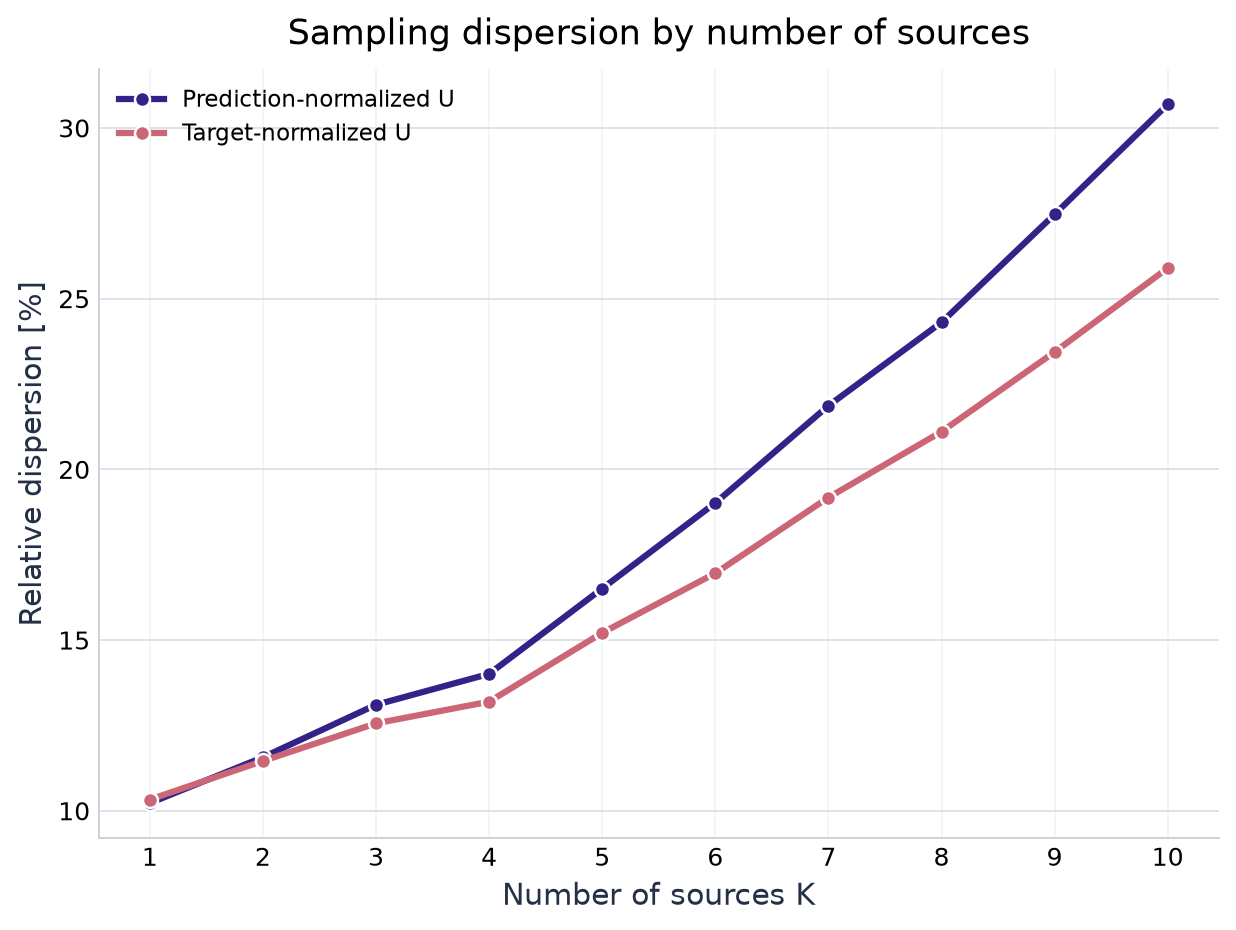

,u_pred,u_true
K,,
1,10.225151,10.329898
2,11.567692,11.459499
3,13.105998,12.560968
4,14.010121,13.196386
5,16.510637,15.213080
6,19.017473,16.958190
7,21.864760,19.175781
8,24.306085,21.104665
9,27.469883,23.438136


In [4]:
summary = mixture_u.groupby('K')[['u_pred', 'u_true']].mean() * 100
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(7.0, 5.3), dpi=180)
    ax.plot(summary.index, summary.u_pred, color='#332288', marker='o', linewidth=2.5,
            markeredgecolor='white', label='Prediction-normalized U')
    ax.plot(summary.index, summary.u_true, color='#CC6677', marker='o', linewidth=2.5,
            markeredgecolor='white', label='Target-normalized U')
    ax.set_xticks(summary.index); ax.set_xlabel('Number of sources K'); ax.set_ylabel('Relative dispersion [%]')
    ax.set_title('Sampling dispersion by number of sources', pad=10); clean(ax)
    ax.legend(frameon=False); fig.tight_layout(); plt.show()
summary

## 4a. Prediction-normalized uncertainty

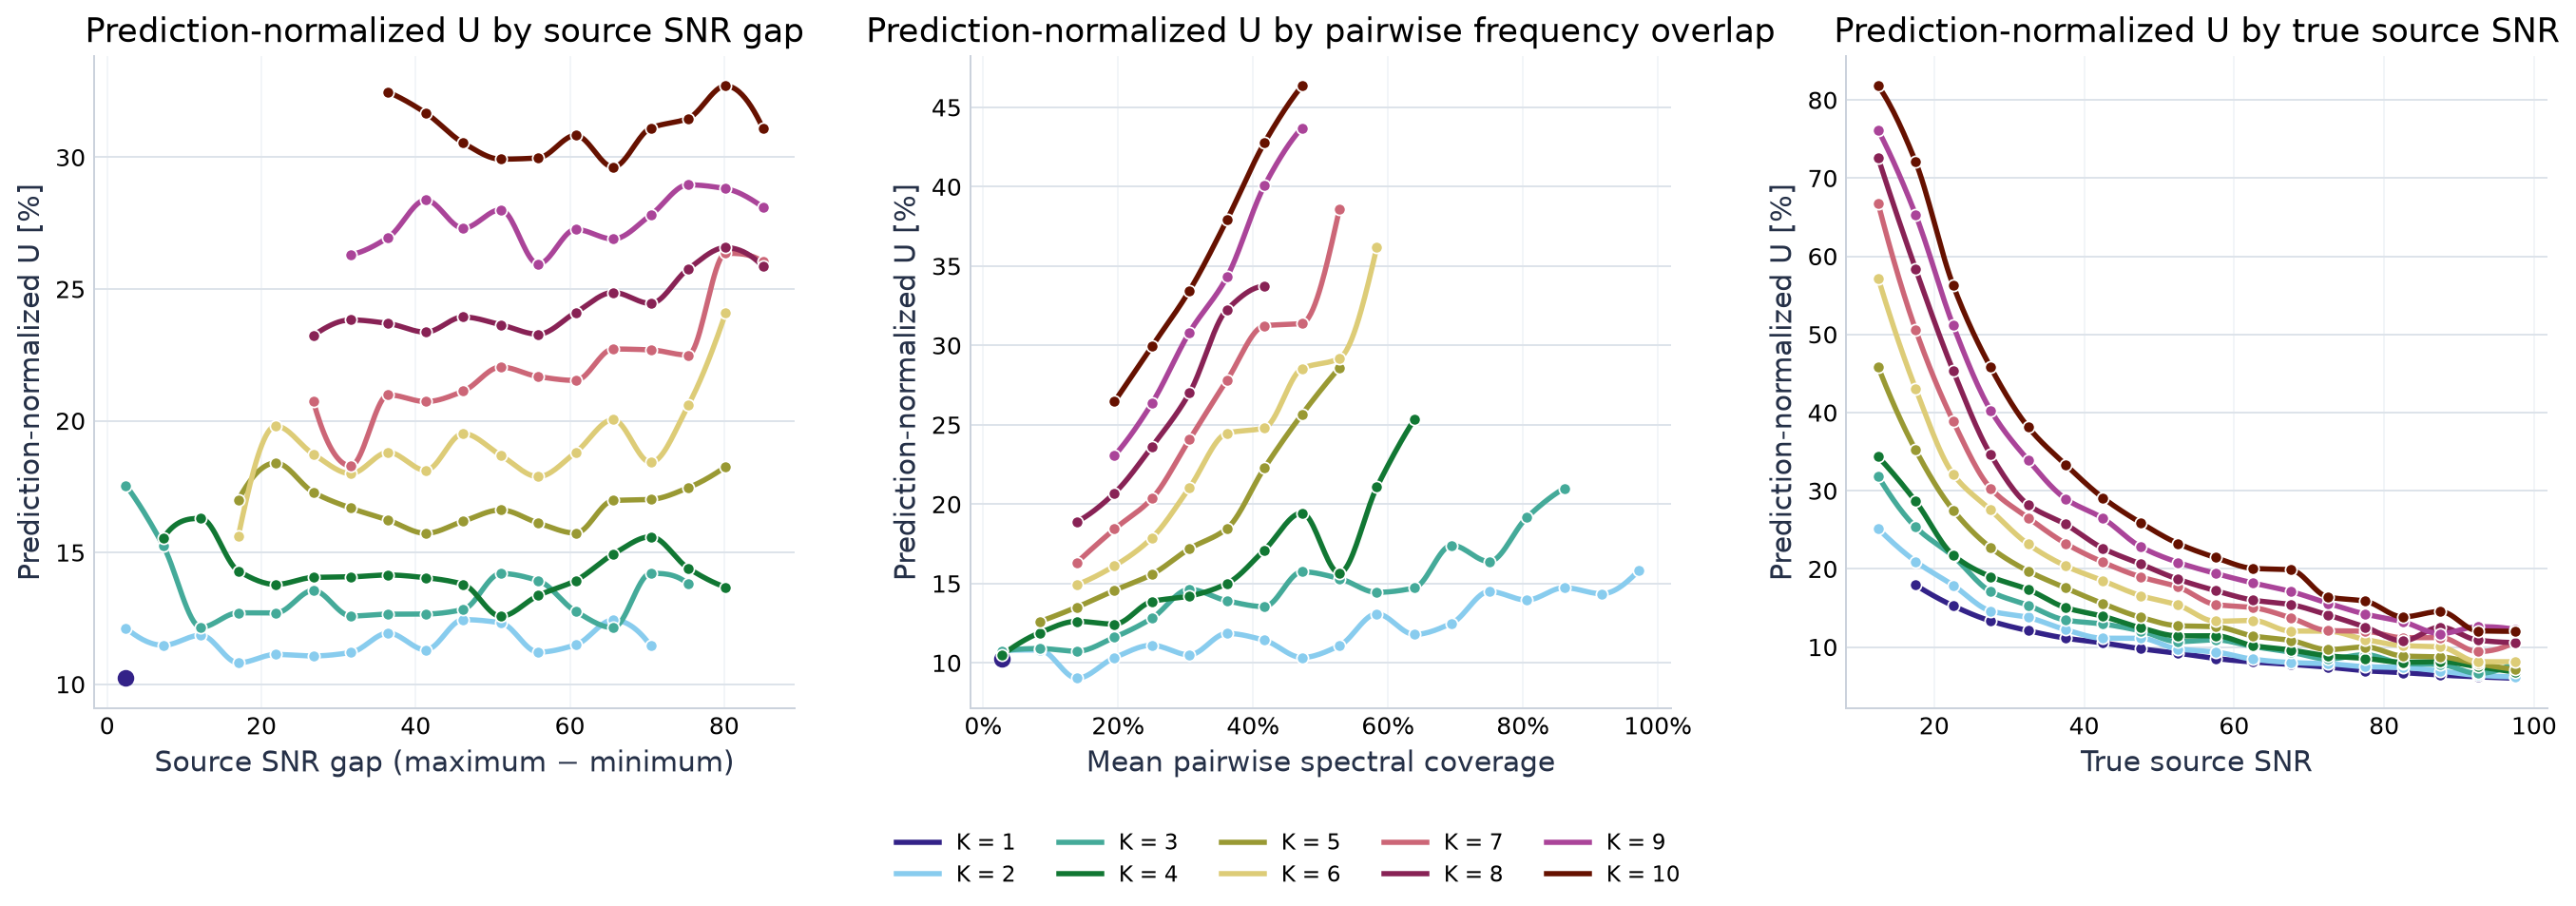

In [5]:
plot_u_dependencies('u_pred', 'Prediction-normalized U')

## 4b. Target-normalized uncertainty

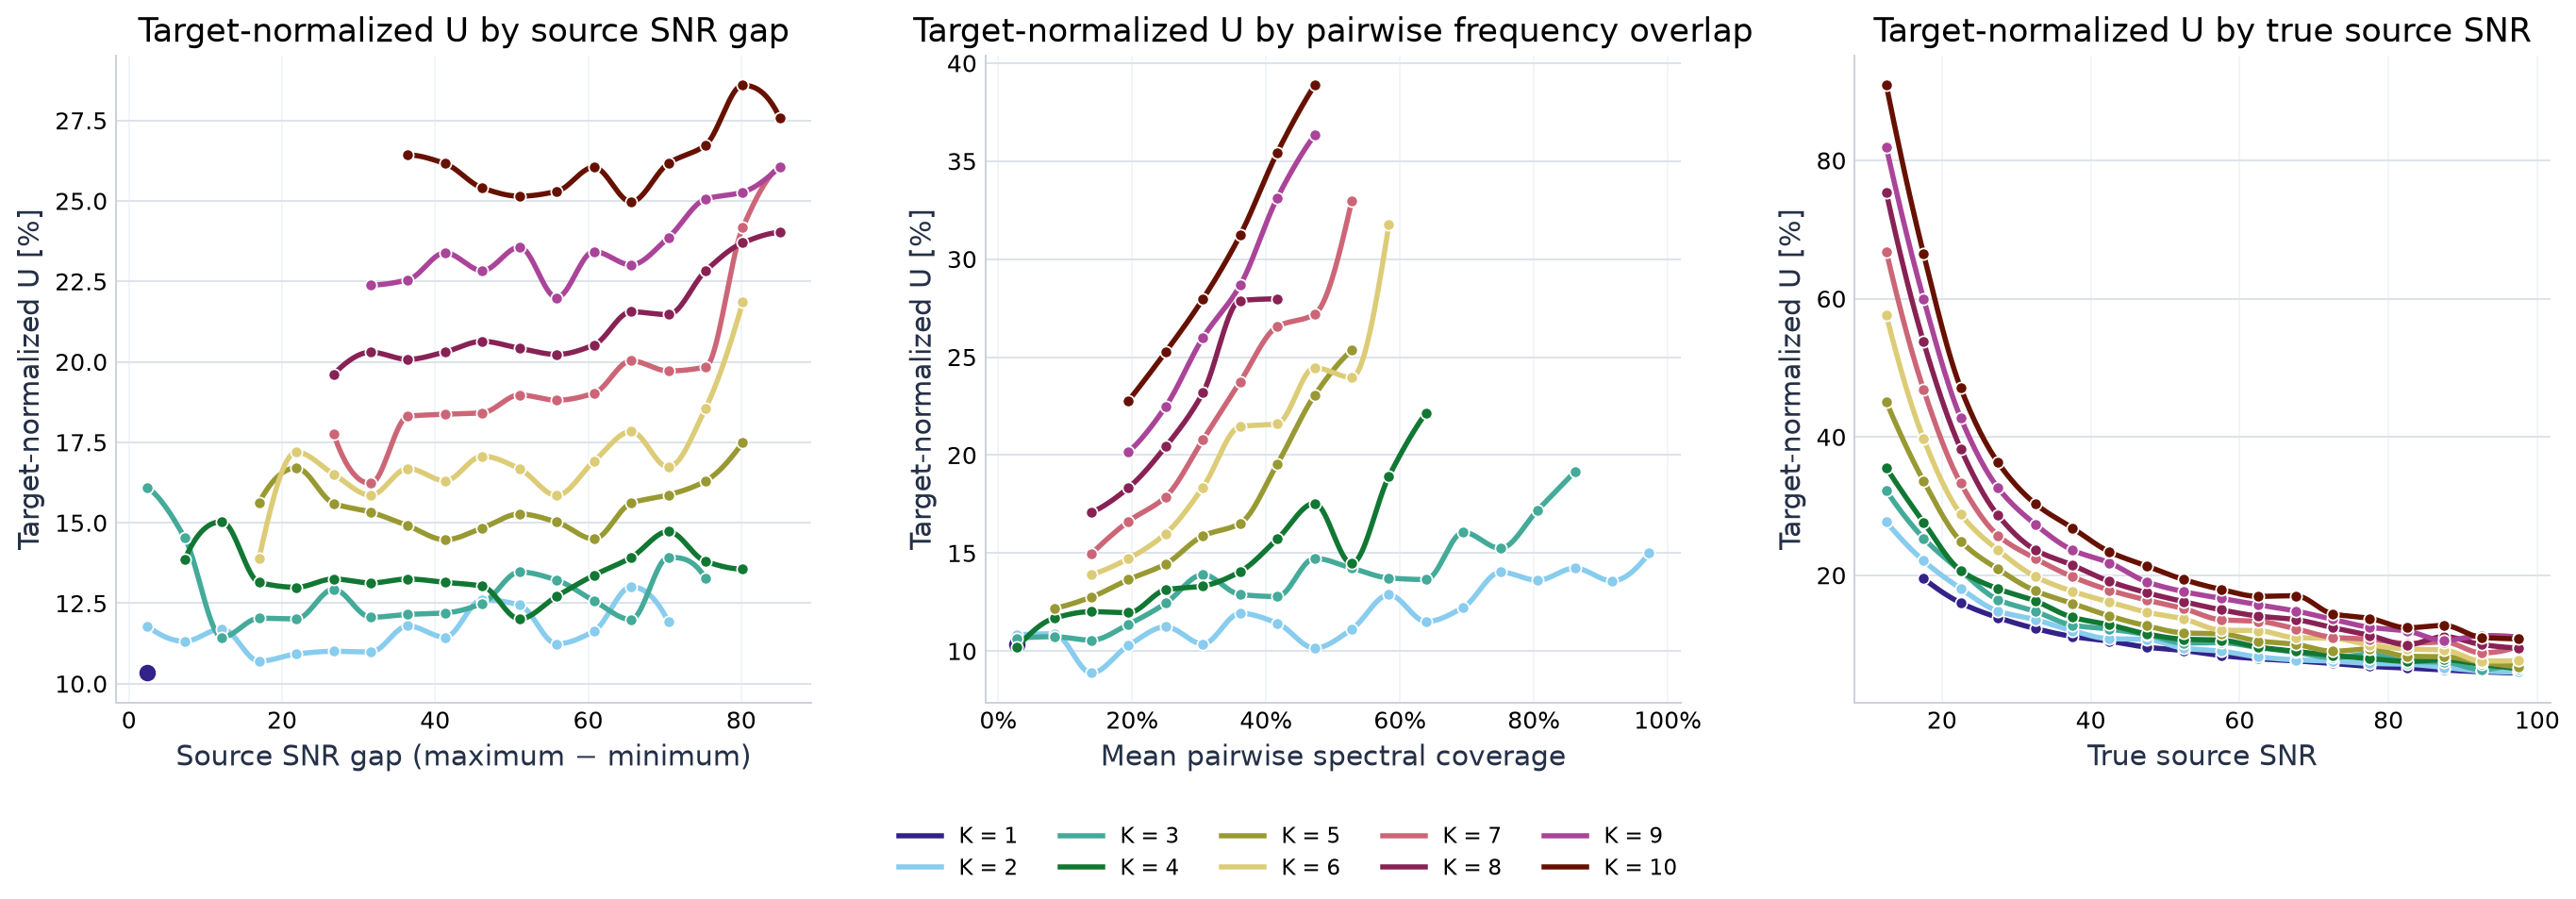

In [6]:
plot_u_dependencies('u_true', 'Target-normalized U')